In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from ibrl.infrabayesian import AMeasure,Infradistribution

In this notebook, we test learning via infradistributions. We consider the following setup:
An agent can choose between multiple actions, each gives a reward or 0 or 1 with a fixed probability (for illustration, imagine it picks one of several biased coins to flip, so the outcomes or T or H). To do this, it has to assign an expected value to each action. Here we consider just one action (i.e. a single biased coin) and see what the expectation values is and how it changes under updates.

The agent considers two possible worlds: P(H)=0.6 and P(H)=0.9. For simplicity, we only place it environments where P(H)=0 or P(H)=1. This is sufficient to see the trends.

We consider the cases where the agent receives a reward upon H or upon T.

In [3]:
# Outcome set: T=0, H=1
U1 = np.array([0,1])  # reward upon H
U0 = np.array([1,0])  # reward upon T
point6 = np.array([0.4,0.6])  # P(H) = 0.6
point9 = np.array([0.1,0.9])  # P(H) = 0.9

In [4]:
# Compute expected values for a given infradistribution, reward function and observation
def compute_expected_values(dist : Infradistribution, U = U1, p = 1, num_obs = 11) -> np.ndarray:
    expected_values = np.empty(num_obs)
    for i in range(num_obs):
        expected_values[i] = dist.expected_value(U)
        dist.update(U,int(np.random.random() < p))
    return expected_values
# Compute expected values for all settings for a given infradistribution
def compute_all_expected_values(dist_factory, num_obs = 11):
    return [
        compute_expected_values(dist_factory(), U0, 0, num_obs),  # reward on T, observe T
        compute_expected_values(dist_factory(), U0, 1, num_obs),  # reward on T, observe H
        compute_expected_values(dist_factory(), U1, 0, num_obs),  # reward on H, observe T
        compute_expected_values(dist_factory(), U1, 1, num_obs)   # reward on H, observe H
    ]
# Create infradistribution from a single measure
def ID(m):
    return Infradistribution([AMeasure.pure(m)])

We consider the following hypotheses
1. KU between 0.6 and 0.9
2. Classical 50-50 prior between 0.6 and 0.9
3. Classical 90-10 prior between 0.6 and 0.9
4. Classical 10-90 prior between 0.6 and 0.9
5. KU between 90-10 and 10-90 prior

Our hypothesis regarding their performance is the following:
- Hypotheses corresponding to classical priors will learn the correct expected value (or rather, the best one that they can represent). However, we need to specify a prior, which can be misspecified, in which we might not converge slowly or not at all and we might take many bad actions in the process.
- Hypotheses corresponding to pure KU (i.e. the set of all classical priors) will not learn. This is because the endpoints of the set assign 100% probability to some possible world. These points do not change under updates. If the extremal points stay fixed, then entire KU remains
- We can remove the extremal points, i.e. we consider KU over the set of classical hypotheses that assign at most 100%-ε probability to any world. This should give us the best of both worlds. We converge to the correct value, but we remain pessimistic in the process.

In [5]:
E1 = compute_all_expected_values(lambda :Infradistribution.mixKU([ID(point6),ID(point9)]))
E2 = compute_all_expected_values(lambda: Infradistribution.mix([ID(point6),ID(point9)],np.array([0.5,0.5])))
E3 = compute_all_expected_values(lambda: Infradistribution.mix([ID(point6),ID(point9)],np.array([0.9,0.1])))
E4 = compute_all_expected_values(lambda: Infradistribution.mix([ID(point6),ID(point9)],np.array([0.1,0.9])))
E5 = compute_all_expected_values(lambda: Infradistribution.mixKU([
    Infradistribution.mix([ID(point6),ID(point9)],np.array([0.9,0.1])),
    Infradistribution.mix([ID(point6),ID(point9)],np.array([0.1,0.9]))
]))

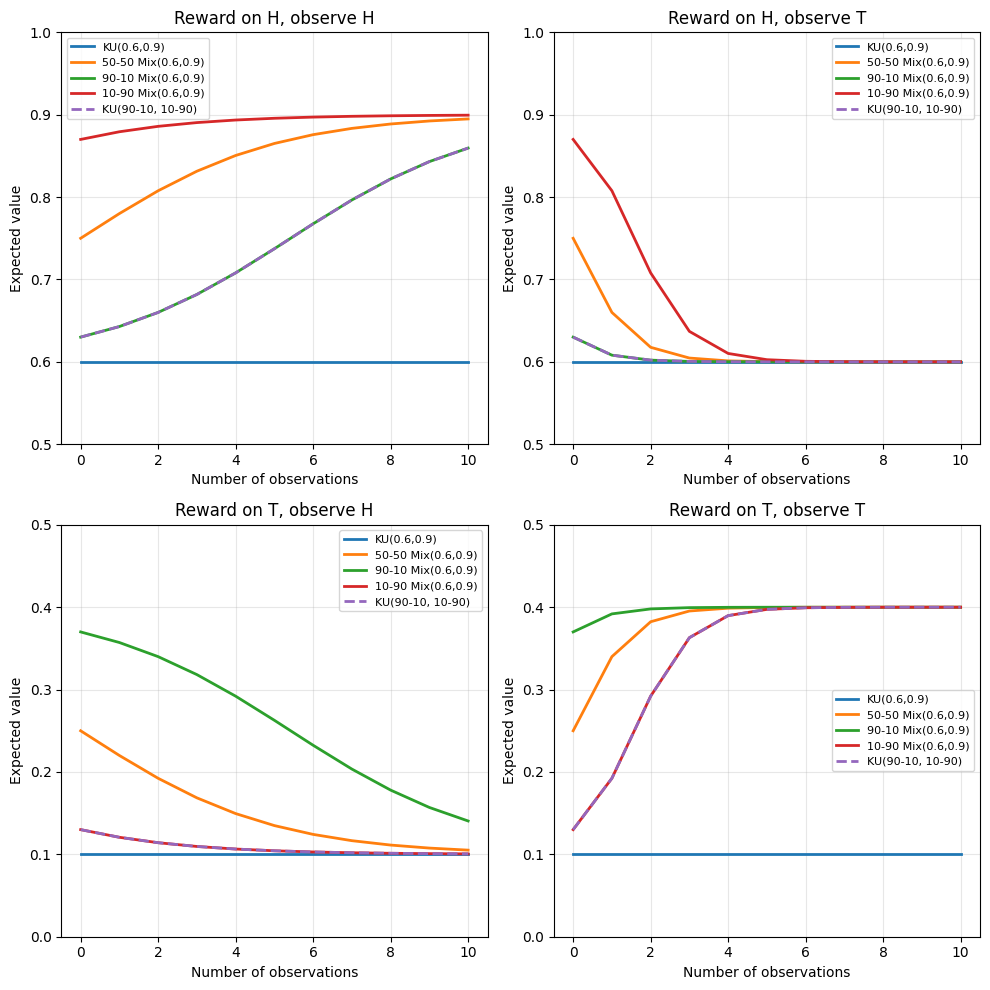

In [6]:
fig, axes = plt.subplots(2,2,figsize=(10,10))
ax = axes[0]
def draw_plots(ax, idx, label):
    ax.plot(E1[idx], label="KU(0.6,0.9)", linewidth=2, ls="-")
    ax.plot(E2[idx], label="50-50 Mix(0.6,0.9)", linewidth=2, ls="-")
    ax.plot(E3[idx], label="90-10 Mix(0.6,0.9)", linewidth=2, ls="-")
    ax.plot(E4[idx], label="10-90 Mix(0.6,0.9)", linewidth=2, ls="-")
    ax.plot(E5[idx], label="KU(90-10, 10-90)", linewidth=2, ls="--")
    ax.set_title(label)
    ax.set_xlabel("Number of observations")
    ax.set_ylabel("Expected value")
    ax.set_ylim([0,0.5] if idx <= 1 else [0.5,1])
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

draw_plots(axes[0,0], 3, "Reward on H, observe H")
draw_plots(axes[0,1], 2, "Reward on H, observe T")
draw_plots(axes[1,0], 1, "Reward on T, observe H")
draw_plots(axes[1,1], 0, "Reward on T, observe T")

plt.tight_layout()
plt.show()

This confirms out expectations. The classical priors converge the fastest, but in doing so, they overestimate the reward significantly and for a long time (see e.g. Reward on T, observe H). The pure KU hypothesis always remains pessimistic and therefore fails to eventually exploit the reward. The KU over priors approach manages to learn the true expected reward in all cases, while only minimally overestimating the expected value at any point.